In [35]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib openpyxl -q

In [36]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 5)

print("Libraries imported successfully.")

Libraries imported successfully.


In [37]:
DATA_PATH = "Dataset.csv"

df = pd.read_csv("/content/Dataset.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (147, 13)


,Feed_T_K,Feed_P_Pa,Feed_xBenzene,Number_of_Stages,Feed_Stage,Reflux_Ratio,Bottoms_Flow_mol_s,Feed_Molar_Flow_mol_s,xD_Benzene,xB_Benzene,QC_kW,QR_kW,Source_File
0,355.84390,100704.93629,0.65342,12,8,1.72114,4.17326,10.00057,0.98544,0.18979,0.48213,0.49354,DWSIM_Benzene_Toluene_Dataset(3).csv
1,372.89482,98322.74494,0.61310,12,9,2.81081,5.40027,10.00057,0.99528,0.28753,0.53190,0.20635,DWSIM_Benzene_Toluene_Dataset(3).csv
2,362.05326,104814.12473,0.49128,10,5,3.21656,5.37848,10.00057,0.96300,0.08589,0.59536,0.60616,DWSIM_Benzene_Toluene_Dataset(3).csv
3,364.89378,109899.42005,0.64244,10,7,3.44713,5.57326,10.00057,0.99596,0.36162,0.59729,0.53520,DWSIM_Benzene_Toluene_Dataset(3).csv
4,367.86233,104591.00710,0.54886,10,8,1.59910,4.00762,10.00057,0.79661,0.17837,0.49050,0.33787,DWSIM_Benzene_Toluene_Dataset(3).csv


In [38]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
for col in df.columns:
    print("-", col)

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

DATASET INFORMATION
Rows: 147
Columns: 13

Column names:
- Feed_T_K
- Feed_P_Pa
- Feed_xBenzene
- Number_of_Stages
- Feed_Stage
- Reflux_Ratio
- Bottoms_Flow_mol_s
- Feed_Molar_Flow_mol_s
- xD_Benzene
- xB_Benzene
- QC_kW
- QR_kW
- Source_File

Data types:


,0
Feed_T_K,float64
Feed_P_Pa,float64
Feed_xBenzene,float64
Number_of_Stages,int64
Feed_Stage,int64
Reflux_Ratio,float64
Bottoms_Flow_mol_s,float64
Feed_Molar_Flow_mol_s,float64
xD_Benzene,float64
xB_Benzene,float64



Missing values:


,0
Feed_T_K,0
Feed_P_Pa,0
Feed_xBenzene,0
Number_of_Stages,0
Feed_Stage,0
Reflux_Ratio,0
Bottoms_Flow_mol_s,0
Feed_Molar_Flow_mol_s,0
xD_Benzene,0
xB_Benzene,0



Duplicate rows:
0


In [39]:
INPUT_FEATURES = [
    "Feed_T_K",
    "Feed_P_Pa",
    "Feed_xBenzene",
    "Number_of_Stages",
    "Feed_Stage",
    "Reflux_Ratio",
    "Bottoms_Flow_mol_s"
]

TARGETS = [
    "xD_Benzene",
    "xB_Benzene",
    "QC_kW",
    "QR_kW"
]

X = df[INPUT_FEATURES].copy()
y = df[TARGETS].copy()

print("Input features:")
display(X.head())

print("\nTarget variables:")
display(y.head())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input features:


,Feed_T_K,Feed_P_Pa,Feed_xBenzene,Number_of_Stages,Feed_Stage,Reflux_Ratio,Bottoms_Flow_mol_s
0,355.84390,100704.93629,0.65342,12,8,1.72114,4.17326
1,372.89482,98322.74494,0.61310,12,9,2.81081,5.40027
2,362.05326,104814.12473,0.49128,10,5,3.21656,5.37848
3,364.89378,109899.42005,0.64244,10,7,3.44713,5.57326
4,367.86233,104591.00710,0.54886,10,8,1.59910,4.00762



Target variables:


,xD_Benzene,xB_Benzene,QC_kW,QR_kW
0,0.98544,0.18979,0.48213,0.49354
1,0.99528,0.28753,0.53190,0.20635
2,0.96300,0.08589,0.59536,0.60616
3,0.99596,0.36162,0.59729,0.53520
4,0.79661,0.17837,0.49050,0.33787



X shape: (147, 7)
y shape: (147, 4)


In [40]:
INPUT_FEATURES = [
    "Feed_T_K",
    "Feed_P_Pa",
    "Feed_xBenzene",
    "Number_of_Stages",
    "Feed_Stage",
    "Reflux_Ratio",
    "Bottoms_Flow_mol_s"
]

TARGETS = [
    "xD_Benzene",
    "xB_Benzene",
    "QC_kW",
    "QR_kW"
]

X = df[INPUT_FEATURES].copy()
y = df[TARGETS].copy()

print("Input features:")
display(X.head())

print("\nTarget variables:")
display(y.head())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input features:


,Feed_T_K,Feed_P_Pa,Feed_xBenzene,Number_of_Stages,Feed_Stage,Reflux_Ratio,Bottoms_Flow_mol_s
0,355.84390,100704.93629,0.65342,12,8,1.72114,4.17326
1,372.89482,98322.74494,0.61310,12,9,2.81081,5.40027
2,362.05326,104814.12473,0.49128,10,5,3.21656,5.37848
3,364.89378,109899.42005,0.64244,10,7,3.44713,5.57326
4,367.86233,104591.00710,0.54886,10,8,1.59910,4.00762



Target variables:


,xD_Benzene,xB_Benzene,QC_kW,QR_kW
0,0.98544,0.18979,0.48213,0.49354
1,0.99528,0.28753,0.53190,0.20635
2,0.96300,0.08589,0.59536,0.60616
3,0.99596,0.36162,0.59729,0.53520
4,0.79661,0.17837,0.49050,0.33787



X shape: (147, 7)
y shape: (147, 4)


In [41]:
print("=" * 60)
print("PHYSICAL CONSISTENCY CHECKS")
print("=" * 60)

checks = {
    "Feed composition >= 0": (df["Feed_xBenzene"] >= 0).all(),
    "Feed composition <= 1": (df["Feed_xBenzene"] <= 1).all(),
    "Distillate purity >= 0": (df["xD_Benzene"] >= 0).all(),
    "Distillate purity <= 1": (df["xD_Benzene"] <= 1).all(),
    "Bottoms purity >= 0": (df["xB_Benzene"] >= 0).all(),
    "Bottoms purity <= 1": (df["xB_Benzene"] <= 1).all(),
    "Condenser duty >= 0": (df["QC_kW"] >= 0).all(),
    "Reboiler duty >= 0": (df["QR_kW"] >= 0).all()
}

for name, result in checks.items():
    print(f"{name:<35}: {'PASS' if result else 'FAIL'}")

PHYSICAL CONSISTENCY CHECKS
Feed composition >= 0              : PASS
Feed composition <= 1              : PASS
Distillate purity >= 0             : PASS
Distillate purity <= 1             : PASS
Bottoms purity >= 0                : PASS
Bottoms purity <= 1                : PASS
Condenser duty >= 0                : PASS
Reboiler duty >= 0                 : PASS


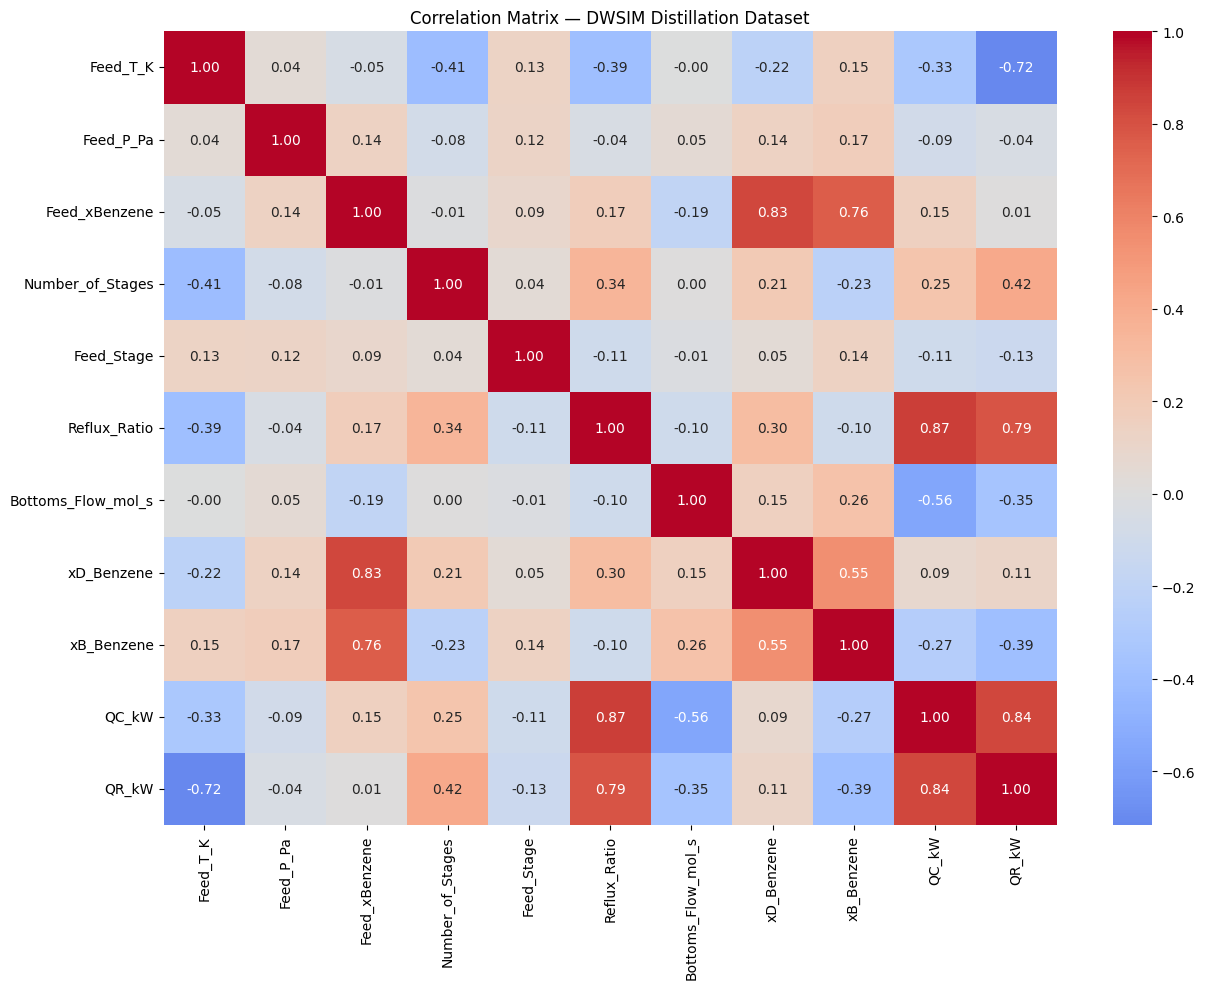

In [42]:
plt.figure(figsize=(13, 10))

corr = df[INPUT_FEATURES + TARGETS].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix — DWSIM Distillation Dataset")
plt.tight_layout()

plt.savefig(
    "01_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

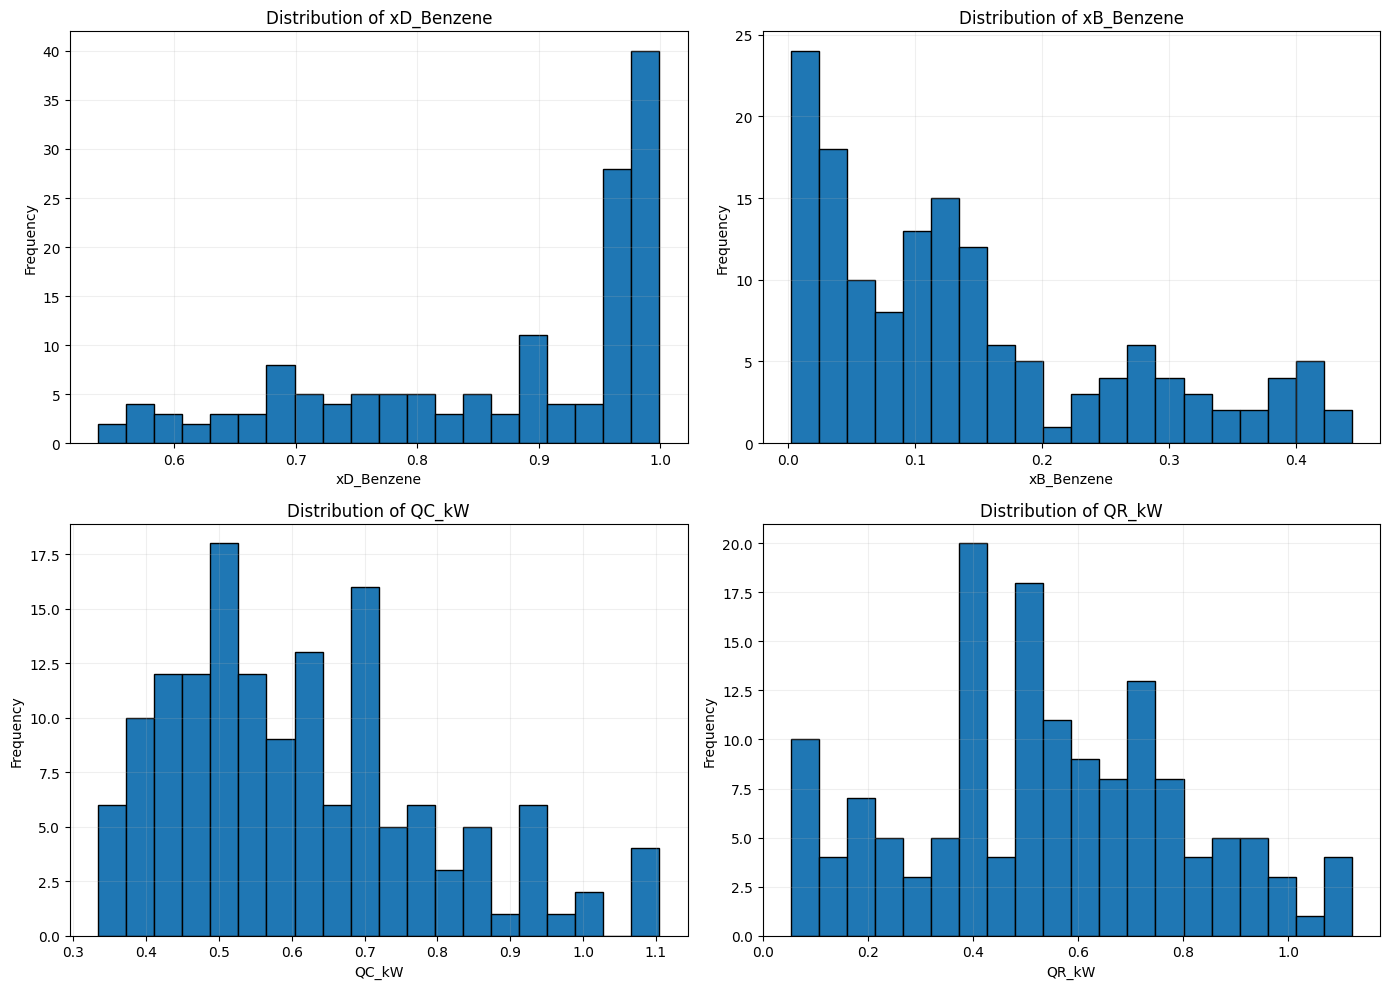

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, target in zip(axes.ravel(), TARGETS):
    ax.hist(df[target], bins=20, edgecolor="black")
    ax.set_title(f"Distribution of {target}")
    ax.set_xlabel(target)
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "02_target_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
stage_summary = df.groupby("Number_of_Stages")[TARGETS].mean()

display(stage_summary)

,xD_Benzene,xB_Benzene,QC_kW,QR_kW
Number_of_Stages,,,,
10,0.84201,0.16356,0.57406,0.44595
12,0.89789,0.10812,0.66286,0.66378


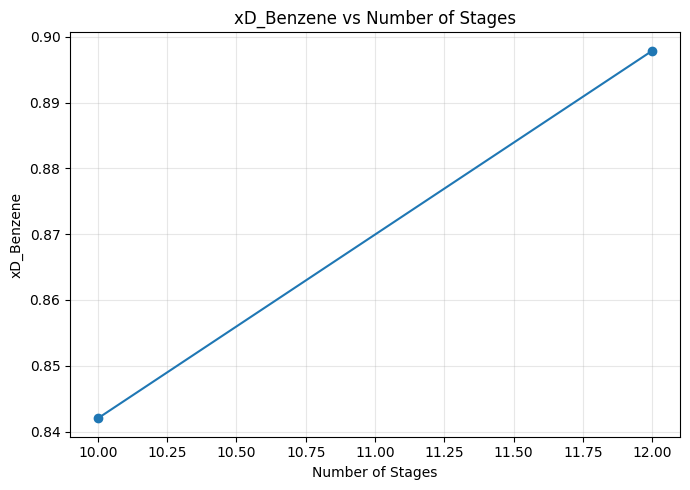

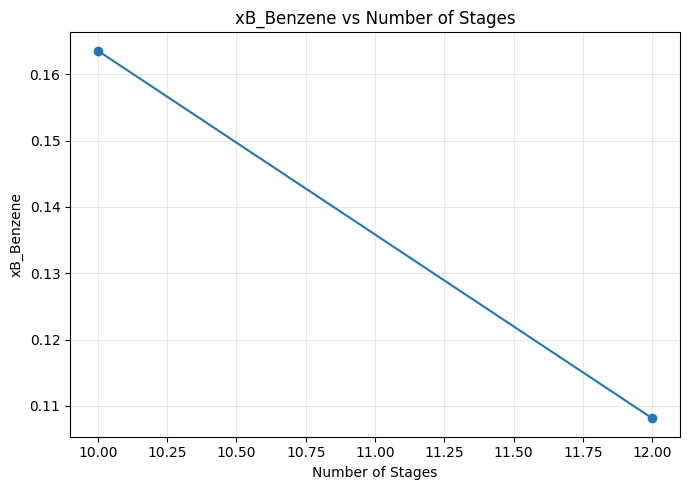

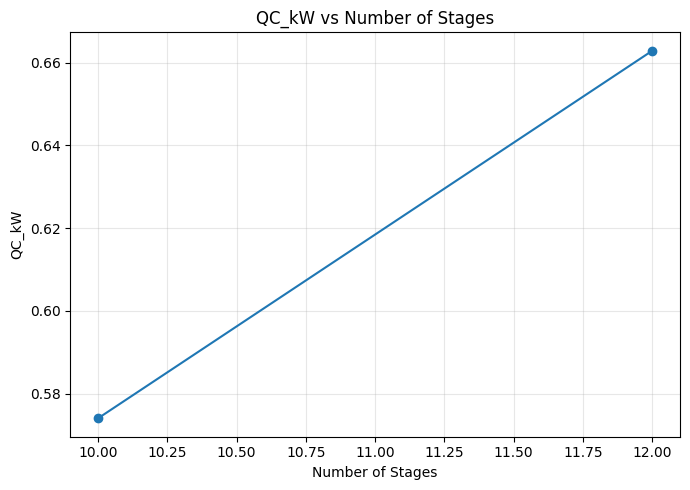

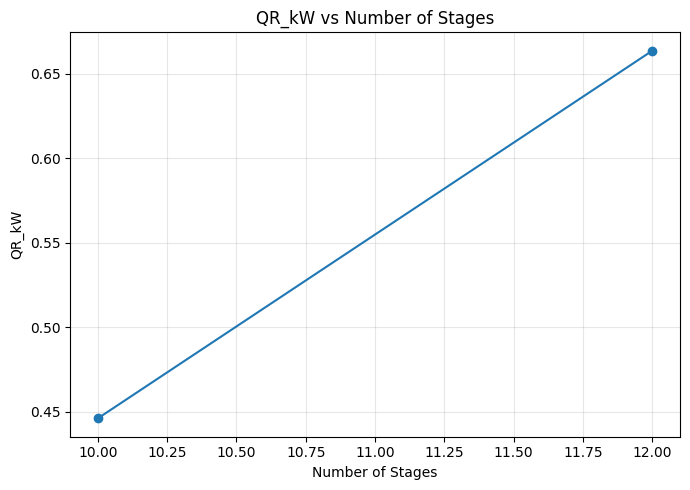

In [45]:
for target in TARGETS:

    plt.figure(figsize=(7, 5))

    stage_means = df.groupby("Number_of_Stages")[target].mean()

    plt.plot(
        stage_means.index,
        stage_means.values,
        marker="o"
    )

    plt.xlabel("Number of Stages")
    plt.ylabel(target)
    plt.title(f"{target} vs Number of Stages")
    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        f"03_{target}_vs_stages.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 117
Testing samples : 30


In [47]:
models = {

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "ANN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            learning_rate_init=0.001,
            max_iter=2000,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=42
        ))
    ])
}

print("Models defined:")
for name in models:
    print("-", name)

Models defined:
- Linear Regression
- Random Forest
- XGBoost
- ANN


In [48]:
trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(
        X_train,
        y_train
    )

    trained_models[name] = model

    print(f"{name} trained successfully.")

print("\nAll models trained.")


Training Linear Regression...
Linear Regression trained successfully.

Training Random Forest...
Random Forest trained successfully.

Training XGBoost...
XGBoost trained successfully.

Training ANN...
ANN trained successfully.

All models trained.


In [49]:
predictions = {}

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    predictions[name] = pd.DataFrame(
        y_pred,
        columns=TARGETS,
        index=y_test.index
    )

print("Predictions generated.")

Predictions generated.


In [50]:
results = []

for model_name, pred_df in predictions.items():

    for target in TARGETS:

        actual = y_test[target]
        predicted = pred_df[target]

        mae = mean_absolute_error(
            actual,
            predicted
        )

        rmse = np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        )

        r2 = r2_score(
            actual,
            predicted
        )

        results.append({
            "Model": model_name,
            "Target": target,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Target,MAE,RMSE,R2
0,Linear Regression,xD_Benzene,0.04327,0.05006,0.86843
1,Linear Regression,xB_Benzene,0.04419,0.05082,0.80604
2,Linear Regression,QC_kW,0.01617,0.02093,0.98563
3,Linear Regression,QR_kW,0.05711,0.06733,0.93594
4,Random Forest,xD_Benzene,0.03225,0.04767,0.88070
5,Random Forest,xB_Benzene,0.03459,0.04836,0.82438
6,Random Forest,QC_kW,0.04009,0.05060,0.91605
7,Random Forest,QR_kW,0.07435,0.11342,0.81820
8,XGBoost,xD_Benzene,0.03055,0.04271,0.90425
9,XGBoost,xB_Benzene,0.01944,0.02713,0.94472


In [51]:
comparison = results_df.pivot(
    index="Model",
    columns="Target",
    values="R2"
)

print("R² comparison:")
display(comparison)

R² comparison:


Target,QC_kW,QR_kW,xB_Benzene,xD_Benzene
Model,,,,
ANN,0.88700,0.93304,0.38447,0.81378
Linear Regression,0.98563,0.93594,0.80604,0.86843
Random Forest,0.91605,0.81820,0.82438,0.88070
XGBoost,0.98880,0.91728,0.94472,0.90425


In [52]:
overall_results = (
    results_df
    .groupby("Model")[["MAE", "RMSE", "R2"]]
    .mean()
    .sort_values("R2", ascending=False)
)

print("Overall average performance:")
display(overall_results)

Overall average performance:


,MAE,RMSE,R2
Model,,,
XGBoost,0.02785,0.04121,0.93876
Linear Regression,0.04018,0.04729,0.89901
Random Forest,0.04532,0.06501,0.85983
ANN,0.05169,0.06941,0.75457


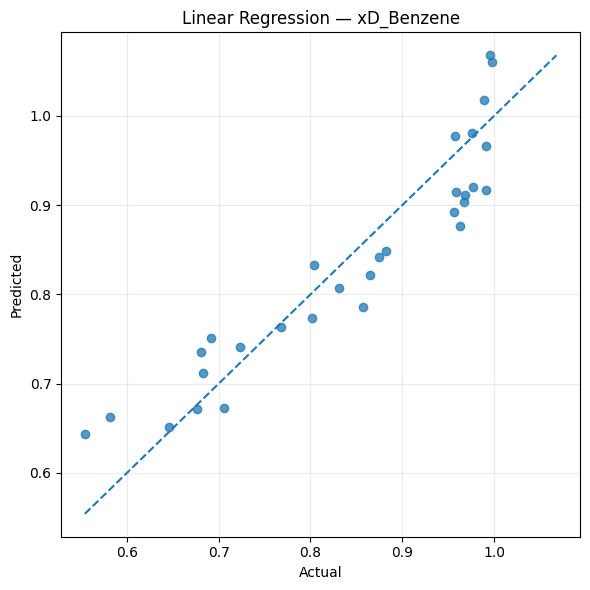

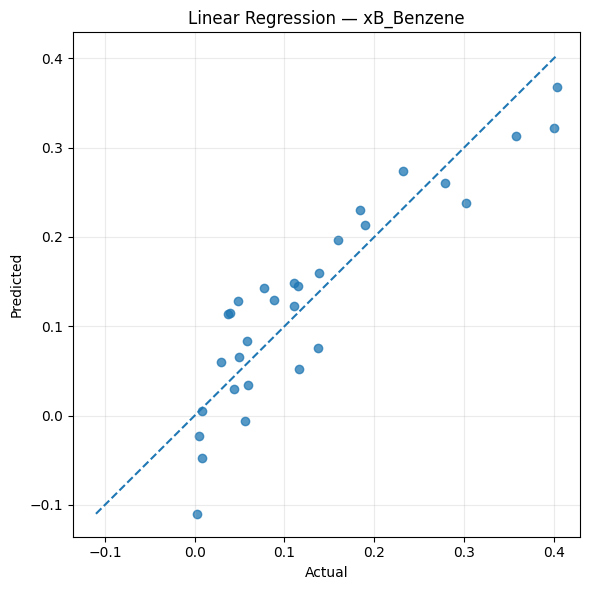

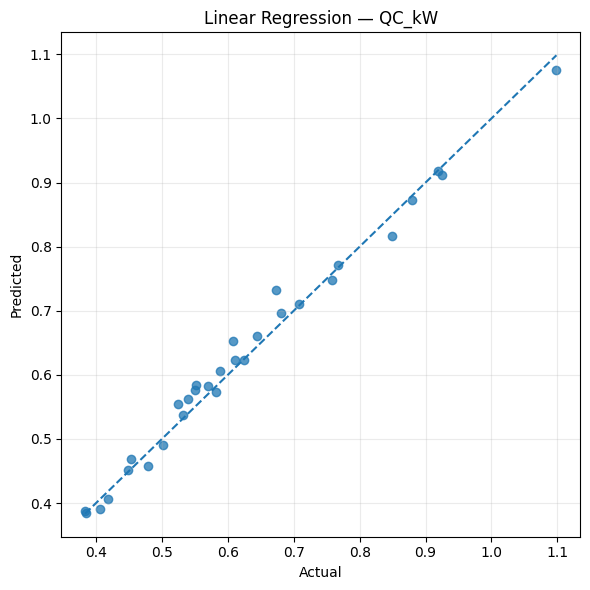

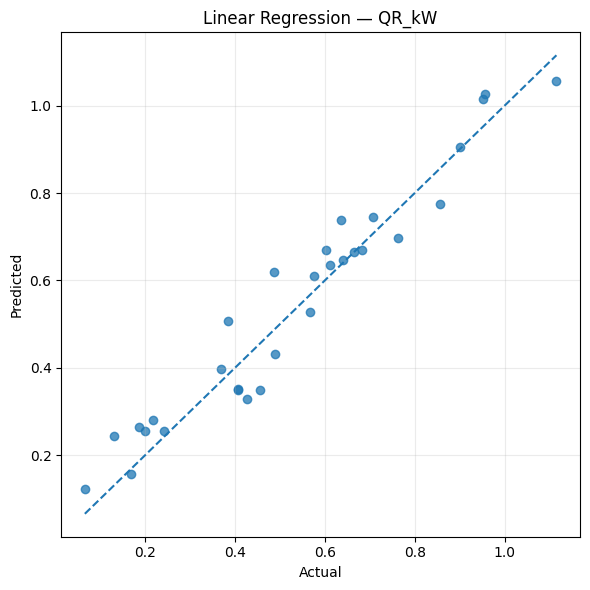

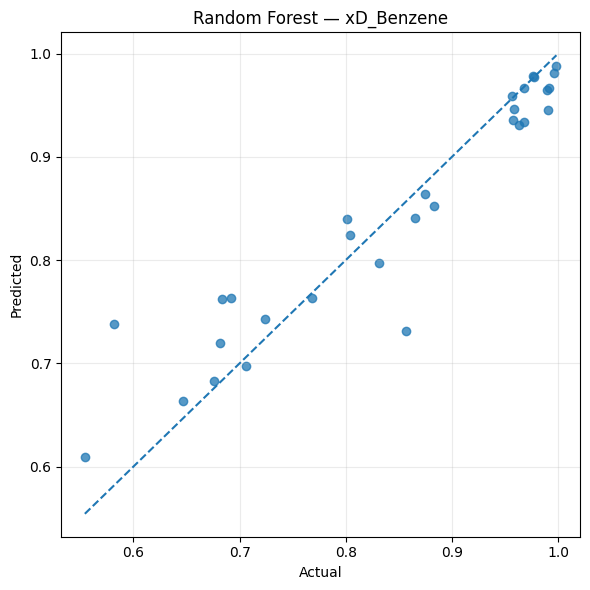

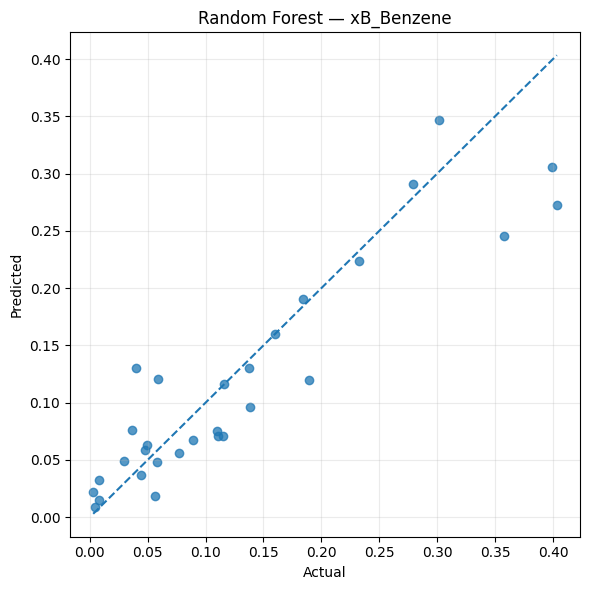

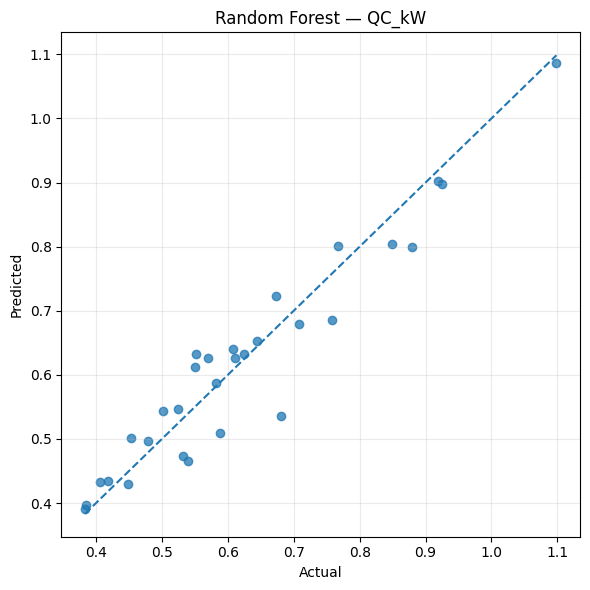

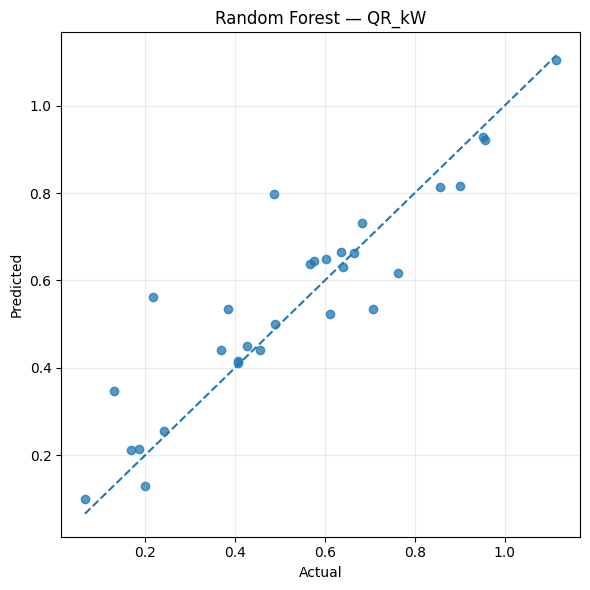

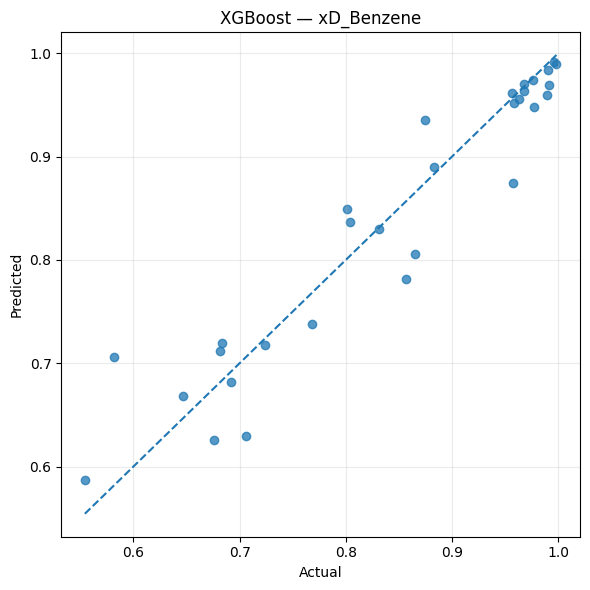

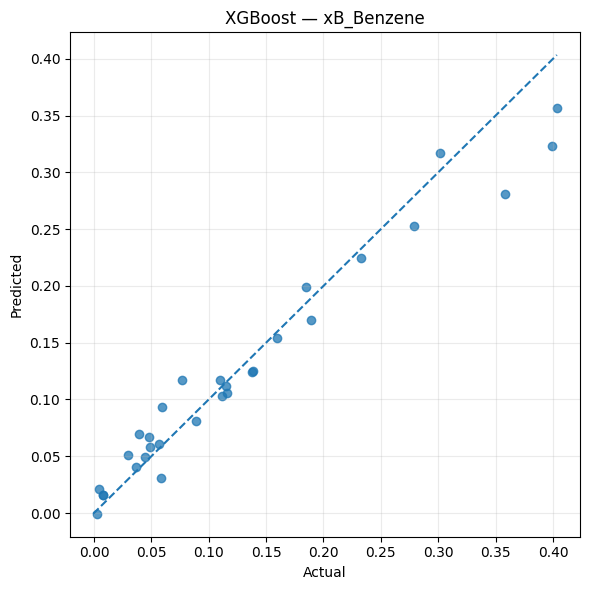

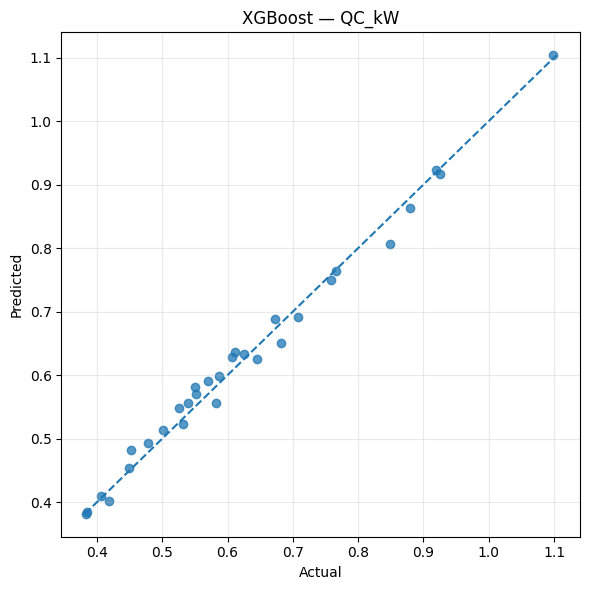

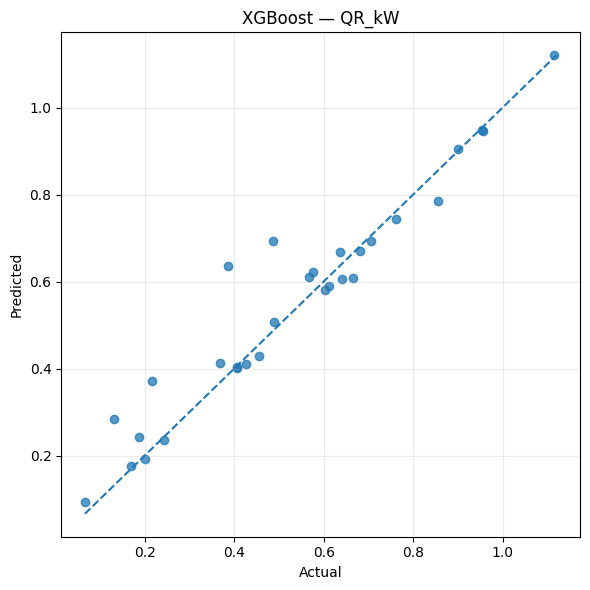

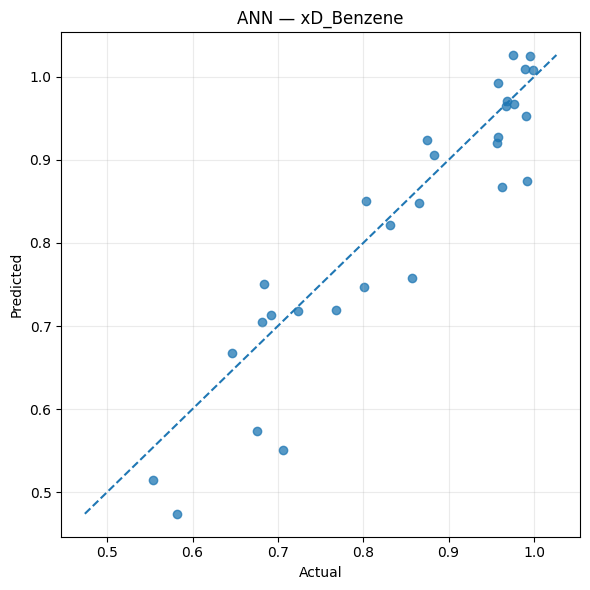

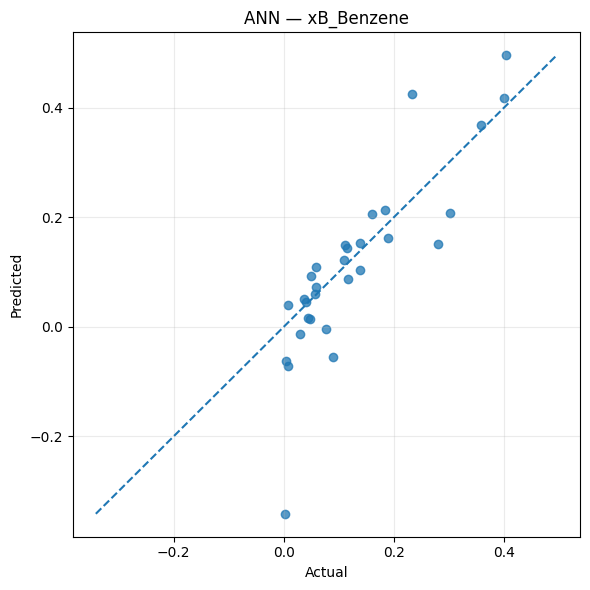

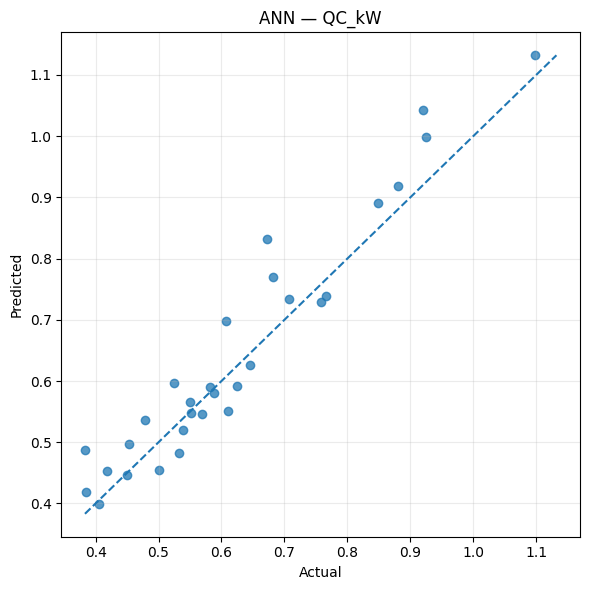

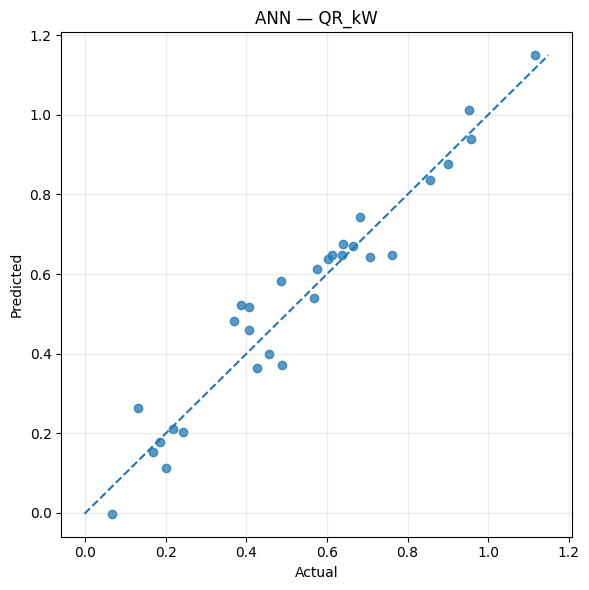

In [53]:
for model_name, pred_df in predictions.items():

    for target in TARGETS:

        plt.figure(figsize=(6, 6))

        actual = y_test[target]
        predicted = pred_df[target]

        plt.scatter(
            actual,
            predicted,
            alpha=0.75
        )

        min_val = min(
            actual.min(),
            predicted.min()
        )

        max_val = max(
            actual.max(),
            predicted.max()
        )

        plt.plot(
            [min_val, max_val],
            [min_val, max_val],
            linestyle="--"
        )

        plt.xlabel("Actual")
        plt.ylabel("Predicted")

        plt.title(
            f"{model_name} — {target}"
        )

        plt.grid(alpha=0.25)

        plt.tight_layout()

        safe_model = model_name.replace(" ", "_")

        plt.savefig(
            f"04_{safe_model}_{target}_predicted_vs_actual.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

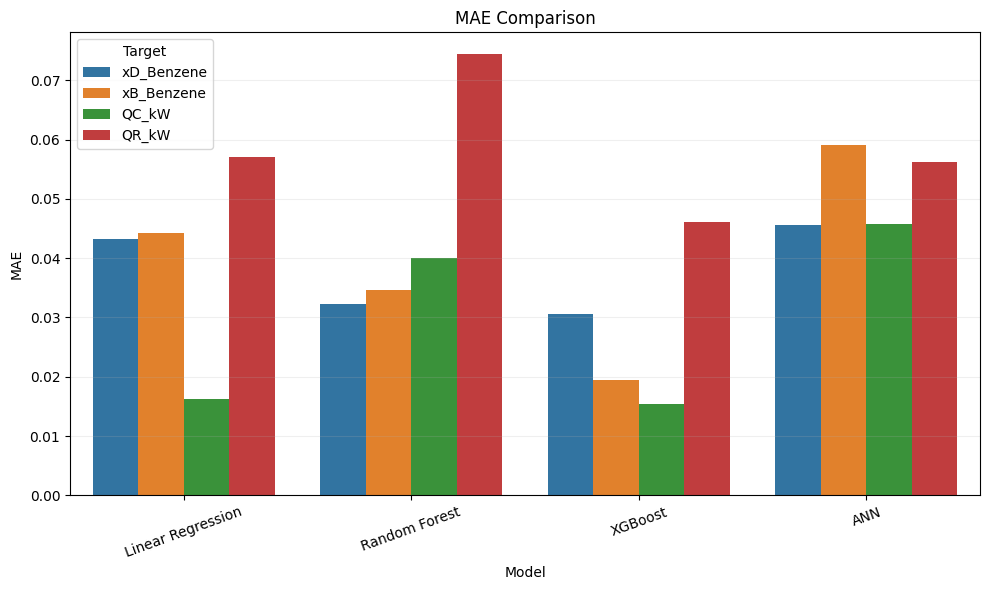

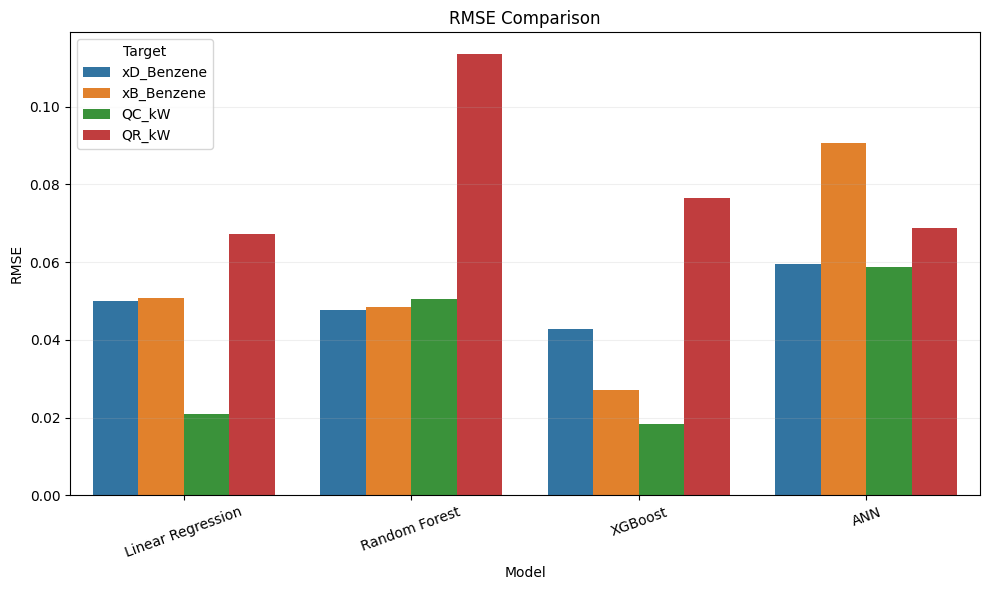

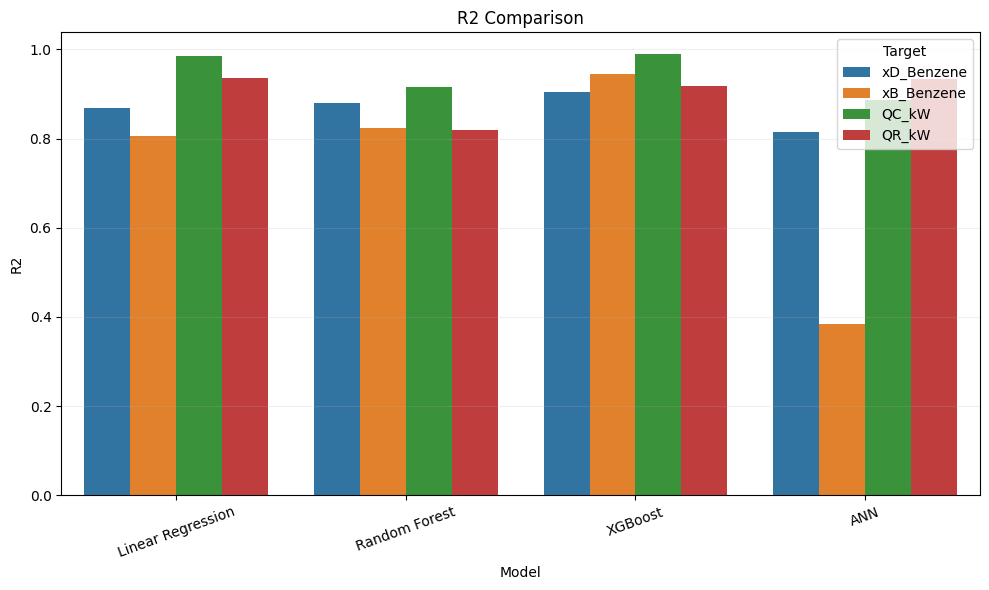

In [54]:
for metric in ["MAE", "RMSE", "R2"]:

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=results_df,
        x="Model",
        y=metric,
        hue="Target"
    )

    plt.title(f"{metric} Comparison")
    plt.xticks(rotation=20)
    plt.grid(axis="y", alpha=0.2)

    plt.tight_layout()

    plt.savefig(
        f"05_{metric}_comparison.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [55]:
rf_model = trained_models["Random Forest"]

importance = pd.DataFrame({
    "Feature": INPUT_FEATURES,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(importance)

,Feature,Importance
5,Reflux_Ratio,0.50704
2,Feed_xBenzene,0.19774
6,Bottoms_Flow_mol_s,0.14518
0,Feed_T_K,0.12293
1,Feed_P_Pa,0.01122
4,Feed_Stage,0.01112
3,Number_of_Stages,0.00478


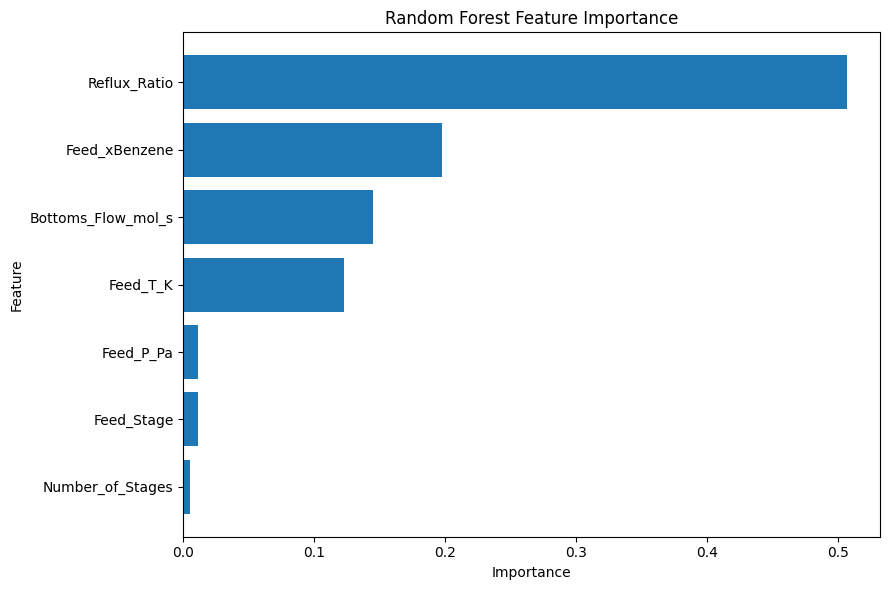

In [56]:
plt.figure(figsize=(9, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "06_random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
xgb_model = trained_models["XGBoost"]

xgb_importance = pd.DataFrame({
    "Feature": INPUT_FEATURES,
    "Importance": xgb_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(xgb_importance)

,Feature,Importance
5,Reflux_Ratio,0.39503
0,Feed_T_K,0.17383
2,Feed_xBenzene,0.16401
6,Bottoms_Flow_mol_s,0.15357
3,Number_of_Stages,0.06580
1,Feed_P_Pa,0.03476
4,Feed_Stage,0.01300


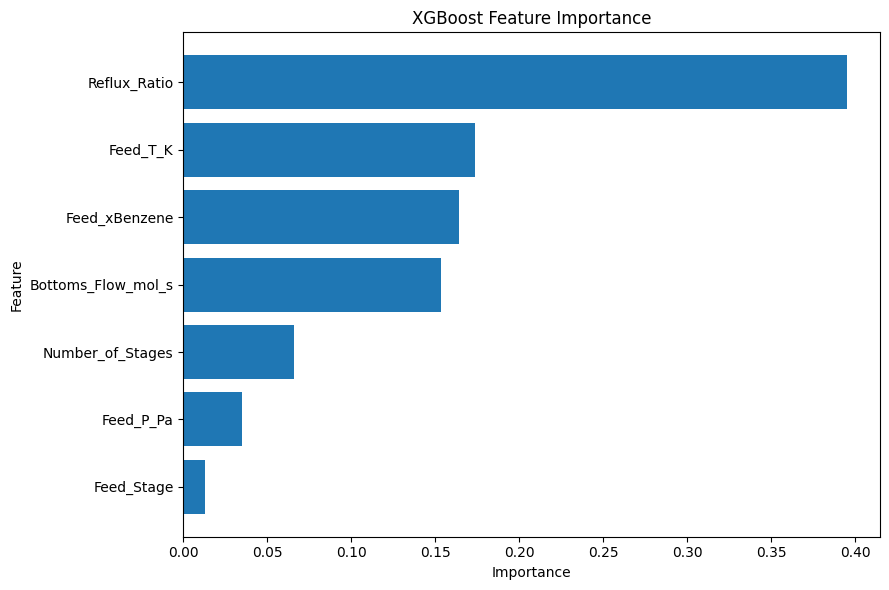

In [58]:
plt.figure(figsize=(9, 6))

plt.barh(
    xgb_importance["Feature"],
    xgb_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "07_xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
physical_prediction_results = []

for model_name, pred_df in predictions.items():

    xD_pred = pred_df["xD_Benzene"]
    xB_pred = pred_df["xB_Benzene"]

    physical_prediction_results.append({
        "Model": model_name,
        "xD_below_0": int((xD_pred < 0).sum()),
        "xD_above_1": int((xD_pred > 1).sum()),
        "xB_below_0": int((xB_pred < 0).sum()),
        "xB_above_1": int((xB_pred > 1).sum()),
    })

physical_df = pd.DataFrame(
    physical_prediction_results
)

display(physical_df)

,Model,xD_below_0,xD_above_1,xB_below_0,xB_above_1
0,Linear Regression,0,3,4,0
1,Random Forest,0,0,0,0
2,XGBoost,0,0,1,0
3,ANN,0,4,6,0


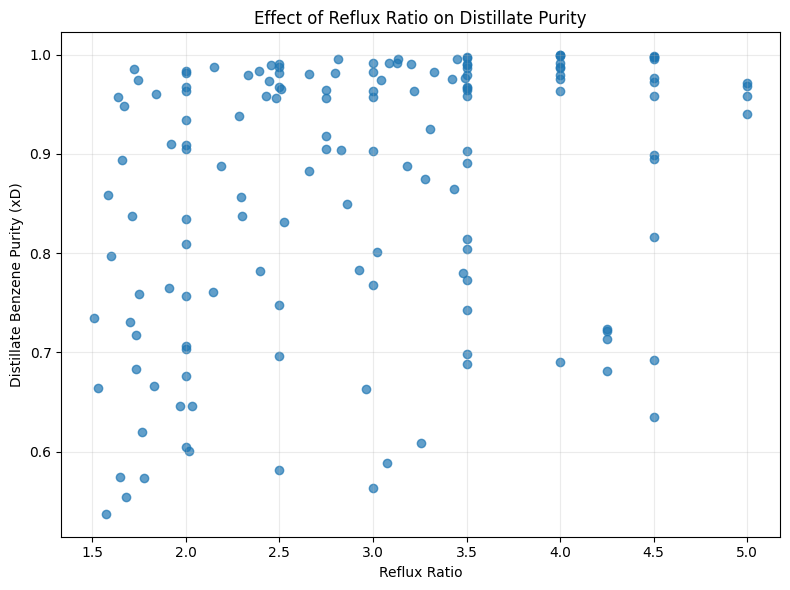

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Reflux_Ratio"],
    df["xD_Benzene"],
    alpha=0.7
)

plt.xlabel("Reflux Ratio")
plt.ylabel("Distillate Benzene Purity (xD)")
plt.title("Effect of Reflux Ratio on Distillate Purity")

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "08_reflux_vs_xD.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

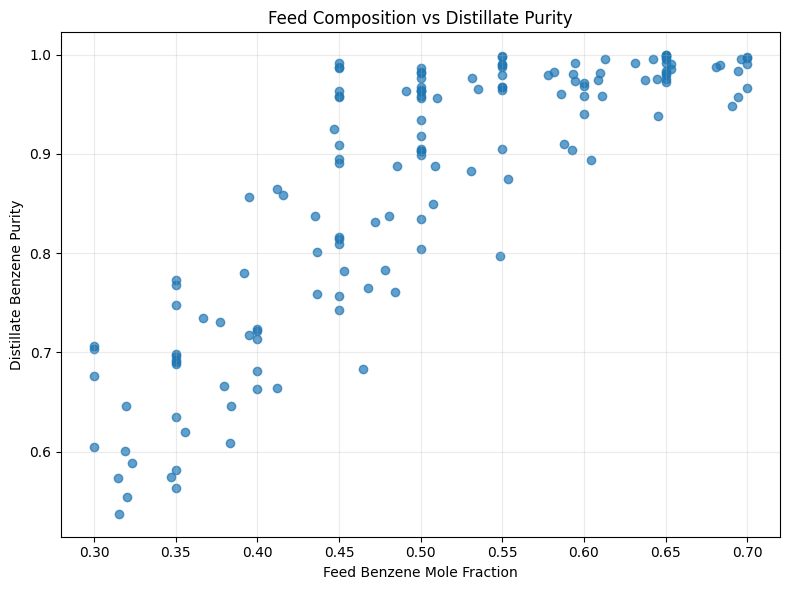

In [61]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Feed_xBenzene"],
    df["xD_Benzene"],
    alpha=0.7
)

plt.xlabel("Feed Benzene Mole Fraction")
plt.ylabel("Distillate Benzene Purity")
plt.title("Feed Composition vs Distillate Purity")

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "09_feed_composition_vs_xD.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
model_ranking = (
    results_df
    .groupby("Model")
    .agg({
        "MAE": "mean",
        "RMSE": "mean",
        "R2": "mean"
    })
    .sort_values(
        "R2",
        ascending=False
    )
)

print("MODEL RANKING")
display(model_ranking)

best_model_name = model_ranking.index[0]

print(
    "\nBest model based on average R²:",
    best_model_name
)

MODEL RANKING


,MAE,RMSE,R2
Model,,,
XGBoost,0.02785,0.04121,0.93876
Linear Regression,0.04018,0.04729,0.89901
Random Forest,0.04532,0.06501,0.85983
ANN,0.05169,0.06941,0.75457



Best model based on average R²: XGBoost


In [63]:
best_results = results_df[
    results_df["Model"] == best_model_name
].copy()

display(best_results)

,Model,Target,MAE,RMSE,R2
8,XGBoost,xD_Benzene,0.03055,0.04271,0.90425
9,XGBoost,xB_Benzene,0.01944,0.02713,0.94472
10,XGBoost,QC_kW,0.01538,0.01848,0.98880
11,XGBoost,QR_kW,0.04604,0.07651,0.91728


In [64]:
prediction_output = X_test.copy()

for target in TARGETS:
    prediction_output[f"Actual_{target}"] = y_test[target]

for model_name, pred_df in predictions.items():

    safe_name = model_name.replace(" ", "_")

    for target in TARGETS:

        prediction_output[
            f"{safe_name}_Pred_{target}"
        ] = pred_df[target]

prediction_output = prediction_output.reset_index(drop=True)

prediction_output.to_csv(
    "Model_Predictions.csv",
    index=False
)

print("Saved: Model_Predictions.csv")

Saved: Model_Predictions.csv


In [65]:
results_df.to_csv(
    "Model_Performance_Comparison.csv",
    index=False
)

model_ranking.to_csv(
    "Model_Ranking.csv"
)

print("Saved:")
print("- Model_Performance_Comparison.csv")
print("- Model_Ranking.csv")

Saved:
- Model_Performance_Comparison.csv
- Model_Ranking.csv


In [66]:
os.makedirs("trained_models", exist_ok=True)

for name, model in trained_models.items():

    filename = (
        name
        .lower()
        .replace(" ", "_")
        .replace("-", "")
        + ".joblib"
    )

    joblib.dump(
        model,
        os.path.join(
            "trained_models",
            filename
        )
    )

print("All trained models saved.")

All trained models saved.


In [67]:
best_row = model_ranking.iloc[0]

summary = f"""
BENZENE-TOLUENE DISTILLATION SURROGATE MODEL
==================================================

Dataset
-------
Number of unique simulations: {len(df)}
Number of input variables: {len(INPUT_FEATURES)}
Number of output variables: {len(TARGETS)}

Inputs
------
{chr(10).join("- " + x for x in INPUT_FEATURES)}

Outputs
-------
{chr(10).join("- " + x for x in TARGETS)}

Models Compared
---------------
1. Linear Regression
2. Random Forest
3. XGBoost
4. Artificial Neural Network

Train/Test Split
----------------
Training samples: {len(X_train)}
Testing samples: {len(X_test)}

Best Model
----------
{best_model_name}

Average MAE
-----------
{best_row["MAE"]:.6f}

Average RMSE
------------
{best_row["RMSE"]:.6f}

Average R2
----------
{best_row["R2"]:.6f}

Physical Consistency
--------------------
Predictions were checked for physically invalid
benzene purities outside the [0,1] interval.

Dataset limitation
------------------
Successful DWSIM simulations represented 10-stage
and 12-stage columns. No converged 14-stage or
16-stage cases were retained.

Duty convention
---------------
Condenser and reboiler duties were represented as
positive magnitudes for consistent surrogate modeling.
"""

with open(
    "Results_Summary.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(summary)

print(summary)


BENZENE-TOLUENE DISTILLATION SURROGATE MODEL

Dataset
-------
Number of unique simulations: 147
Number of input variables: 7
Number of output variables: 4

Inputs
------
- Feed_T_K
- Feed_P_Pa
- Feed_xBenzene
- Number_of_Stages
- Feed_Stage
- Reflux_Ratio
- Bottoms_Flow_mol_s

Outputs
-------
- xD_Benzene
- xB_Benzene
- QC_kW
- QR_kW

Models Compared
---------------
1. Linear Regression
2. Random Forest
3. XGBoost
4. Artificial Neural Network

Train/Test Split
----------------
Training samples: 117
Testing samples: 30

Best Model
----------
XGBoost

Average MAE
-----------
0.027851

Average RMSE
------------
0.041206

Average R2
----------
0.938764

Physical Consistency
--------------------
Predictions were checked for physically invalid
benzene purities outside the [0,1] interval.

Dataset limitation
------------------
Successful DWSIM simulations represented 10-stage
and 12-stage columns. No converged 14-stage or
16-stage cases were retained.

Duty convention
---------------
Condens

In [68]:
print("=" * 60)
print("GENERATED FILES")
print("=" * 60)

for root, dirs, files in os.walk("."):

    for file in files:

        if (
            file.endswith(".csv")
            or file.endswith(".png")
            or file.endswith(".txt")
            or file.endswith(".joblib")
        ):

            print(
                os.path.join(root, file)
            )

GENERATED FILES
./04_ANN_xB_Benzene_predicted_vs_actual.png
./04_ANN_xD_Benzene_predicted_vs_actual.png
./Dataset.csv
./Model_Ranking.csv
./04_Linear_Regression_xB_Benzene_predicted_vs_actual.png
./04_ANN_QR_kW_predicted_vs_actual.png
./03_xD_Benzene_vs_stages.png
./05_MAE_comparison.png
./08_reflux_vs_xD.png
./04_Linear_Regression_QC_kW_predicted_vs_actual.png
./04_Random_Forest_xD_Benzene_predicted_vs_actual.png
./04_Random_Forest_QC_kW_predicted_vs_actual.png
./03_xB_Benzene_vs_stages.png
./07_xgboost_feature_importance.png
./05_R2_comparison.png
./04_Linear_Regression_xD_Benzene_predicted_vs_actual.png
./04_XGBoost_xB_Benzene_predicted_vs_actual.png
./03_QR_kW_vs_stages.png
./04_Linear_Regression_QR_kW_predicted_vs_actual.png
./06_random_forest_feature_importance.png
./Results_Summary.txt
./04_XGBoost_QR_kW_predicted_vs_actual.png
./Model_Predictions.csv
./04_Random_Forest_QR_kW_predicted_vs_actual.png
./04_XGBoost_QC_kW_predicted_vs_actual.png
./02_target_distributions.png
./01_co

In [69]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.base import clone

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for model_name, model in trained_models.items():

    print(f"Running 5-fold CV for {model_name}...")

    for target in TARGETS:

        y_target = y[target]

        scores = cross_validate(
            clone(model),
            X,
            y_target,
            cv=kf,
            scoring={
                "R2": "r2",
                "MAE": "neg_mean_absolute_error",
                "RMSE": "neg_root_mean_squared_error"
            },
            n_jobs=-1
        )

        cv_results.append({
            "Model": model_name,
            "Target": target,
            "CV_R2_Mean": scores["test_R2"].mean(),
            "CV_R2_STD": scores["test_R2"].std(),
            "CV_MAE_Mean": -scores["test_MAE"].mean(),
            "CV_MAE_STD": scores["test_MAE"].std(),
            "CV_RMSE_Mean": -scores["test_RMSE"].mean(),
            "CV_RMSE_STD": scores["test_RMSE"].std()
        })

cv_df = pd.DataFrame(cv_results)

display(cv_df)

Running 5-fold CV for Linear Regression...
Running 5-fold CV for Random Forest...
Running 5-fold CV for XGBoost...
Running 5-fold CV for ANN...


,Model,Target,CV_R2_Mean,CV_R2_STD,CV_MAE_Mean,CV_MAE_STD,CV_RMSE_Mean,CV_RMSE_STD
0,Linear Regression,xD_Benzene,0.83133,0.03524,0.04415,0.00406,0.05367,0.00566
1,Linear Regression,xB_Benzene,0.81030,0.03631,0.04317,0.00368,0.05185,0.00516
2,Linear Regression,QC_kW,0.98638,0.00292,0.01504,0.00224,0.02030,0.00218
3,Linear Regression,QR_kW,0.91970,0.03639,0.05898,0.00720,0.06914,0.00604
4,Random Forest,xD_Benzene,0.90578,0.01967,0.02959,0.00153,0.04011,0.00469
5,Random Forest,xB_Benzene,0.90814,0.03227,0.02814,0.00315,0.03559,0.00517
6,Random Forest,QC_kW,0.97271,0.00871,0.02124,0.00319,0.02852,0.00434
7,Random Forest,QR_kW,0.90271,0.09329,0.04419,0.01011,0.06889,0.02420
8,XGBoost,xD_Benzene,0.90907,0.03815,0.02956,0.00891,0.03972,0.01241
9,XGBoost,xB_Benzene,0.90980,0.01378,0.02639,0.00366,0.03588,0.00364


In [70]:
cv_df.to_csv(
    "Cross_Validation_Results.csv",
    index=False
)

print("Saved: Cross_Validation_Results.csv")

Saved: Cross_Validation_Results.csv


In [71]:
# ============================================================
# FINAL MODEL RESULTS SUMMARY
# ============================================================

import pandas as pd
import numpy as np

# Load results
test_results = pd.read_csv("Model_Performance_Comparison.csv")
cv_results = pd.read_csv("Cross_Validation_Results.csv")

# Calculate overall CV statistics
cv_overall = (
    cv_results
    .groupby("Model")
    .agg(
        CV_R2_Mean=("CV_R2_Mean", "mean"),
        CV_MAE_Mean=("CV_MAE_Mean", "mean"),
        CV_RMSE_Mean=("CV_RMSE_Mean", "mean")
    )
    .sort_values("CV_R2_Mean", ascending=False)
)

print("=" * 70)
print("FINAL SURROGATE MODEL COMPARISON")
print("=" * 70)

display(cv_overall)

# Best model
best_model = "XGBoost"

print("\nSELECTED FINAL MODEL:", best_model)

# Detailed XGBoost CV results
print("\nXGBoost 5-Fold Cross-Validation:")
display(
    cv_results[cv_results["Model"] == best_model]
)

# Test-set results
print("\nXGBoost Test-Set Results:")
display(
    test_results[test_results["Model"] == best_model]
)

# Save final summary
final_summary = pd.DataFrame({
    "Target": [
        "xD_Benzene",
        "xB_Benzene",
        "QC_kW",
        "QR_kW"
    ],
    "CV_R2_Mean": [
        0.909068,
        0.909801,
        0.973922,
        0.939875
    ],
    "CV_R2_STD": [
        0.038151,
        0.013779,
        0.015010,
        0.043987
    ],
    "CV_MAE": [
        0.029564,
        0.026390,
        0.020224,
        0.038602
    ],
    "CV_RMSE": [
        0.039718,
        0.035879,
        0.027062,
        0.057217
    ]
})

final_summary.to_csv(
    "FINAL_XGBoost_Results.csv",
    index=False
)

print("\nSaved: FINAL_XGBoost_Results.csv")

FINAL SURROGATE MODEL COMPARISON


,CV_R2_Mean,CV_MAE_Mean,CV_RMSE_Mean
Model,,,
XGBoost,0.93317,0.02869,0.03997
Random Forest,0.92234,0.03079,0.04328
Linear Regression,0.88693,0.04034,0.04874
ANN,-0.61625,0.14858,0.18383



SELECTED FINAL MODEL: XGBoost

XGBoost 5-Fold Cross-Validation:


,Model,Target,CV_R2_Mean,CV_R2_STD,CV_MAE_Mean,CV_MAE_STD,CV_RMSE_Mean,CV_RMSE_STD
8,XGBoost,xD_Benzene,0.90907,0.03815,0.02956,0.00891,0.03972,0.01241
9,XGBoost,xB_Benzene,0.90980,0.01378,0.02639,0.00366,0.03588,0.00364
10,XGBoost,QC_kW,0.97392,0.01501,0.02022,0.00457,0.02706,0.00750
11,XGBoost,QR_kW,0.93988,0.04399,0.03860,0.00504,0.05722,0.01301



XGBoost Test-Set Results:


,Model,Target,MAE,RMSE,R2
8,XGBoost,xD_Benzene,0.03055,0.04271,0.90425
9,XGBoost,xB_Benzene,0.01944,0.02713,0.94472
10,XGBoost,QC_kW,0.01538,0.01848,0.98880
11,XGBoost,QR_kW,0.04604,0.07651,0.91728



Saved: FINAL_XGBoost_Results.csv


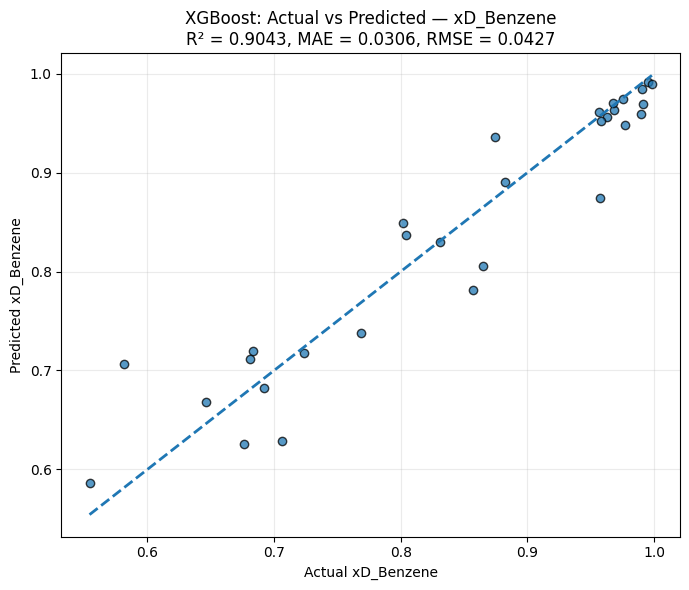

Saved: FINAL_XGBoost_xD_Benzene_Actual_vs_Predicted.png


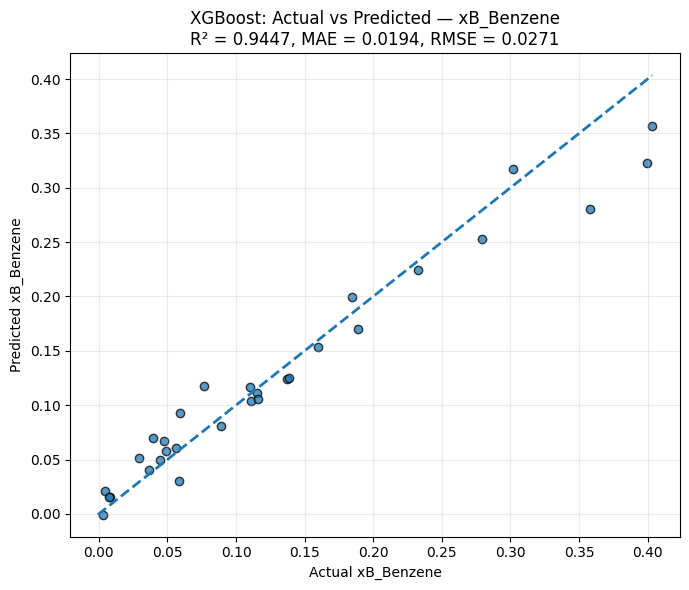

Saved: FINAL_XGBoost_xB_Benzene_Actual_vs_Predicted.png


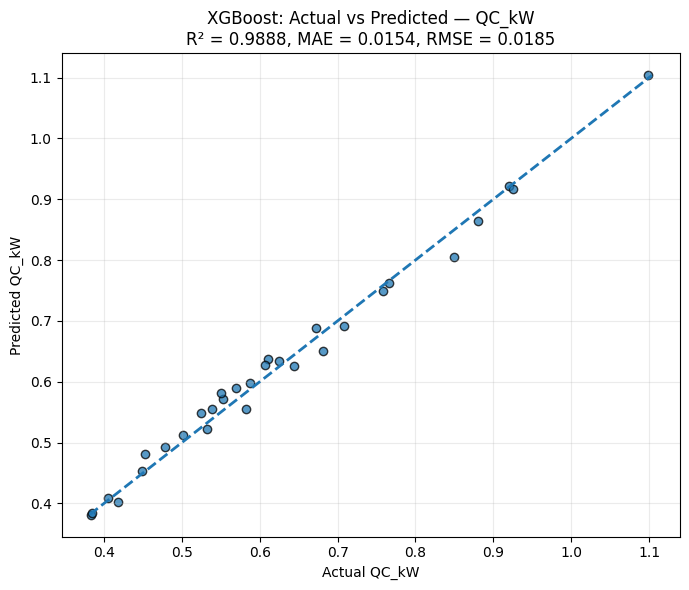

Saved: FINAL_XGBoost_QC_kW_Actual_vs_Predicted.png


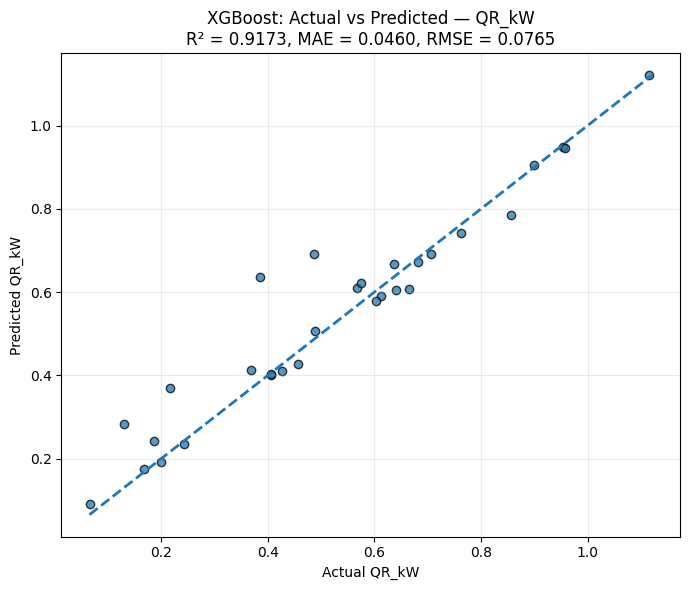

Saved: FINAL_XGBoost_QR_kW_Actual_vs_Predicted.png


In [72]:
# ============================================================
# FINAL XGBOOST PREDICTION PLOTS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

xgb_pred = predictions["XGBoost"]

for target in TARGETS:

    actual = y_test[target]
    predicted = xgb_pred[target]

    plt.figure(figsize=(7, 6))

    plt.scatter(
        actual,
        predicted,
        alpha=0.75,
        edgecolors="black"
    )

    low = min(actual.min(), predicted.min())
    high = max(actual.max(), predicted.max())

    plt.plot(
        [low, high],
        [low, high],
        linestyle="--",
        linewidth=2
    )

    # R2
    from sklearn.metrics import r2_score, mean_absolute_error

    r2 = r2_score(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(
        np.mean((actual - predicted) ** 2)
    )

    plt.xlabel(f"Actual {target}")
    plt.ylabel(f"Predicted {target}")

    plt.title(
        f"XGBoost: Actual vs Predicted — {target}\n"
        f"R² = {r2:.4f}, MAE = {mae:.4f}, RMSE = {rmse:.4f}"
    )

    plt.grid(alpha=0.25)
    plt.tight_layout()

    filename = f"FINAL_XGBoost_{target}_Actual_vs_Predicted.png"

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", filename)

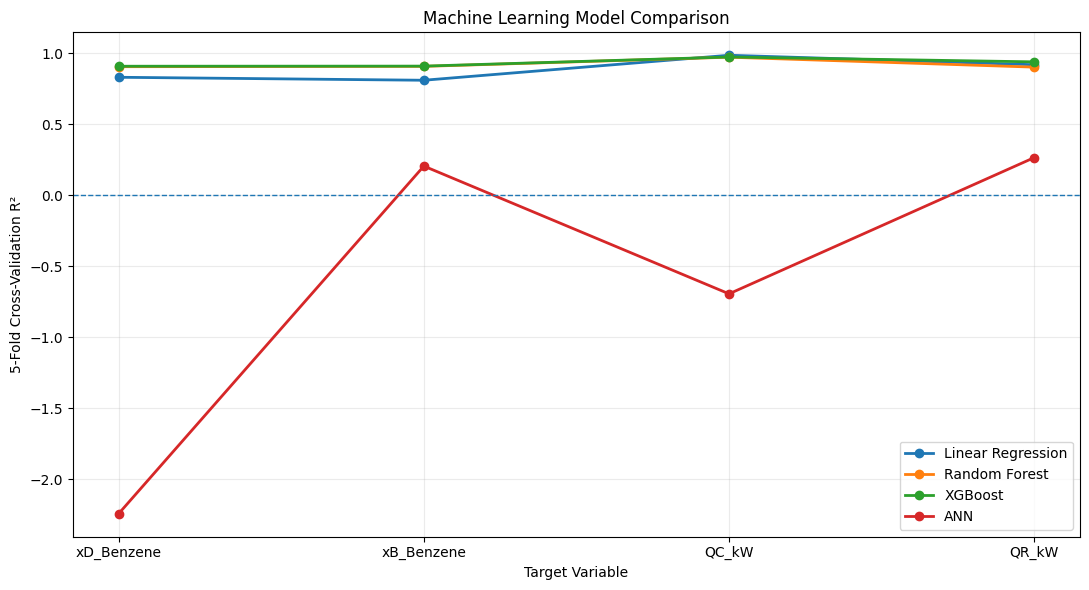

In [73]:
# ============================================================
# FINAL MODEL R2 COMPARISON
# ============================================================

cv_plot = cv_results.copy()

plt.figure(figsize=(11, 6))

for model in cv_plot["Model"].unique():

    temp = cv_plot[cv_plot["Model"] == model]

    plt.plot(
        temp["Target"],
        temp["CV_R2_Mean"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Target Variable")
plt.ylabel("5-Fold Cross-Validation R²")
plt.title("Machine Learning Model Comparison")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "FINAL_Model_Comparison_R2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()